# Contrastive Language-Image Pretraining (CLIP), Step by Step, and Zero-Shot Classification

**CLIP**, developed by OpenAI in 2021, bridges the gap between images and text by placing them in a **shared embedding space**. Using **contrastive learning**, CLIP learns to tell which image-text pairs belong together and which don't.

This ability lets it generalize across different classes, even ones it hasn't explicitly seen during training. As a result, CLIP is highly effective at **zero-shot classification**: it can identify new categories based purely on a text description, with no task-specific fine-tuning at all.

The goal of this lab is to actually understand *why* this works, not just use it as a black box:

1. **Build a small CLIP-style model completely from scratch** (image encoder, text encoder, and the contrastive loss itself), and train it
2. Use this from-scratch model for **zero-shot classification**
3. Compare it against the **real, pretrained OpenAI CLIP model**, to see what training at a much larger scale actually buys you

# Learning Objectives

By the end of this lab, you should be able to:

- explain what a shared embedding space is, and why it enables zero-shot classification
- implement an image encoder and a text encoder that map into the same embedding space
- implement the **contrastive (InfoNCE) loss** used to train CLIP-style models, and explain why it's symmetric (image-to-text *and* text-to-image)
- train a small multimodal model from scratch and use it for zero-shot classification
- compare a from-scratch, toy-scale model against a real pretrained CLIP model, and relate the difference to training scale

# Part 1 — Building Contrastive Learning, Step by Step

## Step 1 — Imports and Setup

In [ ]:
import os
import re
import math
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch version: 2.11.0+cu128
Using device: cuda


## Step 2 — Dataset: FashionMNIST Images Paired With Captions

FashionMNIST has no real captions, so -- just like the original notebook did for its zero-shot labels -- we generate simple templated captions from the class names, e.g. `"a photo of a cat"`. We use a handful of different templates per class, so the model sees a bit of caption diversity rather than a single fixed string per class.

In [ ]:
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),  # scale to [-1, 1], single channel
])

train_raw = datasets.FashionMNIST(root="./data", train=True, download=True)
test_raw = datasets.FashionMNIST(root="./data", train=False, download=True)

class_names = train_raw.classes
print("Classes:", class_names)

CAPTION_TEMPLATES = [
    "a photo of a {}",
    "an image of a {}",
    "a picture of a {}",
    "this is a photo of a {}",
]

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.71MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.8MB/s]


Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [ ]:
class ImageCaptionDataset(Dataset):
    """Wraps a torchvision image classification split, pairing each image with a randomly
    templated caption built from its class name."""
    def __init__(self, base_dataset, class_names, templates, transform):
        self.base_dataset = base_dataset
        self.class_names = class_names
        self.templates = templates
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        image = self.transform(image)
        template = random.choice(self.templates)
        caption = template.format(self.class_names[label])
        return image, caption, label


train_dataset = ImageCaptionDataset(train_raw, class_names, CAPTION_TEMPLATES, img_transform)
test_dataset = ImageCaptionDataset(test_raw, class_names, CAPTION_TEMPLATES, img_transform)

print("Train size:", len(train_dataset), " Test size:", len(test_dataset))
image, caption, label = train_dataset[0]
print("Example:", caption, "| image shape:", image.shape, "| label:", label)

Train size: 60000  Test size: 10000
Example: a photo of a Ankle boot | image shape: torch.Size([1, 28, 28]) | label: 9


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 207kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.0MB/s]


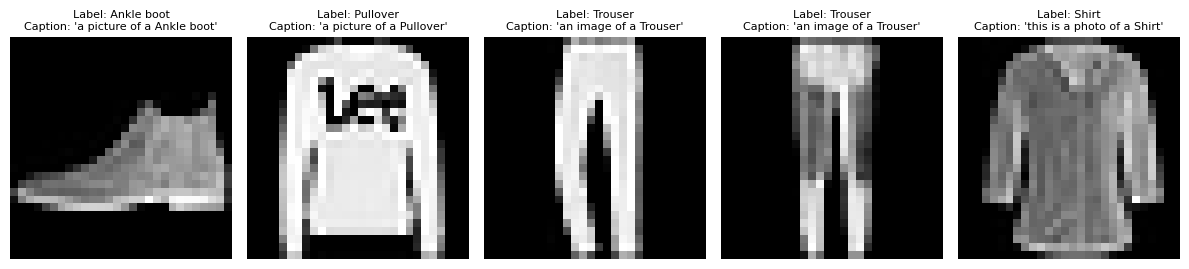

In [2]:
import matplotlib.pyplot as plt

# Safety: make sure test_dataset exists in the global session
if 'test_dataset' not in globals():
    from torchvision import datasets, transforms
    import random
    img_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])
    test_raw = datasets.FashionMNIST(root="./data", train=False, download=True)
    class_names = test_raw.classes
    class ImageCaptionDataset:
        def __init__(self, base_dataset, class_names, templates, transform):
            self.base_dataset = base_dataset
            self.class_names = class_names
            self.templates = templates
            self.transform = transform
        def __len__(self):
            return len(self.base_dataset)
        def __getitem__(self, idx):
            image, label = self.base_dataset[idx]
            image = self.transform(image)
            caption = random.choice(self.templates).format(self.class_names[label])
            return image, caption, label
    CAPTION_TEMPLATES = ["a photo of a {}", "an image of a {}", "a picture of a {}", "this is a photo of a {}"]
    test_dataset = ImageCaptionDataset(test_raw, class_names, CAPTION_TEMPLATES, img_transform)

# Figure size
plt.figure(figsize=(12, 5))

# Fetch and display 5 examples from the test set
for i in range(5):
    image, caption, label = test_dataset[i]

    # Denormalize the image from [-1, 1] to [0, 1] for display
    img_display = (image.squeeze(0).numpy() * 0.5 + 0.5)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img_display, cmap="gray")
    plt.title(f"Label: {class_names[label]}\nCaption: '{caption}'", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

**A design caveat worth being upfront about:** because captions are templated per *class* rather than written individually per *image* (as real CLIP training data is), two different images of the same class that happen to land in the same training batch will get different, unrelated captions treated as "negatives" of each other -- even though those captions are near-identical in meaning. This adds a little label noise to the contrastive objective. Real CLIP mostly avoids this by training on genuinely unique, per-image captions scraped from the web. We'll come back to this in the Final Questions.

## Step 3 — A Tokenizer and Vocabulary for the Captions

Same from-scratch approach as the text-generation labs: our caption vocabulary is tiny, so a simple word-level tokenizer is all we need.

In [ ]:
def tokenize(text):
    return text.lower().split()


counter = Counter()
for template in CAPTION_TEMPLATES:
    for class_name in class_names:
        counter.update(tokenize(template.format(class_name)))

vocab = ["<pad>", "<unk>"] + sorted(counter.keys())
word_to_index = {word: idx for idx, word in enumerate(vocab)}
vocab_size = len(vocab)

max_caption_len = max(len(tokenize(t.format(c))) for t in CAPTION_TEMPLATES for c in class_names)

print("Vocabulary:", vocab)
print("Vocabulary size:", vocab_size)
print("max_caption_len:", max_caption_len)


def encode_caption(caption, max_len=max_caption_len):
    ids = [word_to_index.get(tok, 1) for tok in tokenize(caption)]
    ids = ids[:max_len] + [0] * (max_len - len(ids))
    return ids

Vocabulary: ['<pad>', '<unk>', 'a', 'an', 'ankle', 'bag', 'boot', 'coat', 'dress', 'image', 'is', 'of', 'photo', 'picture', 'pullover', 'sandal', 'shirt', 'sneaker', 't-shirt/top', 'this', 'trouser']
Vocabulary size: 21
max_caption_len: 8


In [ ]:
def collate_batch(batch):
    images, captions, labels = zip(*batch)
    images = torch.stack(images)
    token_ids = torch.tensor([encode_caption(c) for c in captions], dtype=torch.long)
    labels = torch.tensor(labels, dtype=torch.long)
    return images, token_ids, labels


# FashionMNIST's full train split (60,000 images) is still more than a lab really needs to
# see the contrastive loss work -- optionally cap it for faster epochs. Set to None to use
# the full dataset.
TRAIN_SUBSET_SIZE = 6000

if TRAIN_SUBSET_SIZE is not None:
    subset_indices = torch.randperm(len(train_dataset))[:TRAIN_SUBSET_SIZE]
    train_dataset = torch.utils.data.Subset(train_dataset, subset_indices)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

images, tokens, labels = next(iter(train_loader))
print("images:", images.shape, " tokens:", tokens.shape, " labels:", labels.shape)
print("Using", len(train_dataset), "training images")

images: torch.Size([128, 1, 28, 28])  tokens: torch.Size([128, 8])  labels: torch.Size([128])
Using 6000 training images


## Step 4 — Image Encoder

A small CNN that maps an image to a vector in the shared embedding space -- architecturally nothing new compared to the CNNs in the earlier labs.

In [ ]:
class ImageEncoder(nn.Module):
    def __init__(self, embed_dim=128, in_channels=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 28x28 -> 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),            # 14x14 -> 7x7
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),           # 7x7 -> 3x3
        )
        self.fc = nn.Linear(128 * 3 * 3, embed_dim)

    def forward(self, images):
        x = self.conv(images)
        x = x.flatten(1)
        return self.fc(x)  # (batch, embed_dim) -- NOT normalized yet, that happens in MiniCLIP below

## Step 5 — Text Encoder

A minimal encoder: an embedding lookup, mean-pooled over the real (non-padding) tokens, then projected into the same embedding space as the image encoder. Real CLIP uses a full Transformer text encoder (like the one you built in the earlier Transformer text-generation lab) -- we keep this one simple on purpose, since the point of this lab is the *contrastive objective*, which we've already covered text encoders for elsewhere in this course.

In [ ]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=0)
        self.fc = nn.Linear(hidden_dim, embed_dim)

    def forward(self, token_ids):
        # token_ids: (batch, seq_len)
        mask = (token_ids != 0).unsqueeze(-1).float()
        embedded = self.embedding(token_ids) * mask
        pooled = embedded.sum(dim=1) / mask.sum(dim=1).clamp(min=1)  # mean over REAL tokens only
        return self.fc(pooled)  # (batch, embed_dim) -- NOT normalized yet

## Step 6 — The Contrastive (InfoNCE / CLIP) Loss

This is the heart of the lab. Given a batch of `N` (image, caption) pairs:

1. Encode all images and all captions, and **L2-normalize** every embedding (so similarity becomes pure cosine similarity, independent of vector length).
2. Compute the full `N x N` similarity matrix between every image and every caption in the batch, scaled by a learnable **temperature** (`logit_scale`) that controls how "sharp" or "soft" the resulting probabilities are.
3. The matching image-caption pair at position `(i, i)` (the diagonal) is the **positive** pair; every other position in row `i` is a **negative** (some other caption in the batch, presumably describing something different).
4. Because we want this to work in *both* directions -- "find the right caption for this image" and "find the right image for this caption" -- the loss is applied **twice**: once treating each row as a classification problem (`cross_entropy` over `logits_per_image`), and once treating each column as a classification problem (`cross_entropy` over `logits_per_text`, i.e. the transpose). The two are averaged.

This symmetric formulation is exactly what the original CLIP paper calls the **InfoNCE loss**.

In [ ]:
class MiniCLIP(nn.Module):
    def __init__(self, vocab_size, embed_dim=128):
        super().__init__()
        self.image_encoder = ImageEncoder(embed_dim)
        self.text_encoder = TextEncoder(vocab_size, embed_dim)
        # Learnable temperature, initialized like real CLIP (log(1/0.07)); the model
        # can learn to make the similarity distribution sharper or softer over training.
        self.logit_scale = nn.Parameter(torch.log(torch.tensor(1 / 0.07)))

    def forward(self, images, token_ids):
        image_embeds = F.normalize(self.image_encoder(images), dim=-1)
        text_embeds = F.normalize(self.text_encoder(token_ids), dim=-1)

        logit_scale = self.logit_scale.exp()
        logits_per_image = logit_scale * image_embeds @ text_embeds.t()  # (batch, batch)
        logits_per_text = logits_per_image.t()                           # (batch, batch)

        return logits_per_image, logits_per_text, image_embeds, text_embeds


def clip_loss(logits_per_image, logits_per_text):
    batch_size = logits_per_image.shape[0]
    # The positive pair for row/column i is always at index i -- that's how we built the batch
    labels = torch.arange(batch_size, device=logits_per_image.device)

    loss_image_to_text = F.cross_entropy(logits_per_image, labels)
    loss_text_to_image = F.cross_entropy(logits_per_text, labels)

    return (loss_image_to_text + loss_text_to_image) / 2

**Sanity check:** if image and text embeddings were *perfectly* aligned (identical vectors for matching pairs, unrelated otherwise), this loss should be very close to `0`. Let's verify that directly, before trusting it inside a full training loop.

In [ ]:
with torch.no_grad():
    perfect_embeds = F.normalize(torch.randn(16, 128), dim=-1)
    logit_scale = torch.tensor(14.0)  # roughly matches the initial value above
    perfect_logits = logit_scale * perfect_embeds @ perfect_embeds.t()
    perfect_labels = torch.arange(16)
    perfect_loss = F.cross_entropy(perfect_logits, perfect_labels)

print("Loss for perfectly aligned embeddings (should be close to 0):", perfect_loss.item())

Loss for perfectly aligned embeddings (should be close to 0): 2.7186706574866548e-05


## Step 7 — Training Utilities

In [ ]:
def evaluate_loss(model, data_loader, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for images, tokens, _ in data_loader:
            images, tokens = images.to(device), tokens.to(device)
            logits_per_image, logits_per_text, _, _ = model(images, tokens)
            loss = clip_loss(logits_per_image, logits_per_text)
            total_loss += loss.item() * images.size(0)
            total += images.size(0)
    return total_loss / total


def train_clip(model, train_loader, val_loader, device, epochs=15, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total = 0

        for images, tokens, _ in train_loader:
            images, tokens = images.to(device), tokens.to(device)

            optimizer.zero_grad()
            logits_per_image, logits_per_text, _, _ = model(images, tokens)
            loss = clip_loss(logits_per_image, logits_per_text)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            total += images.size(0)

        train_loss = running_loss / total
        val_loss = evaluate_loss(model, val_loader, device)
        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")

    return history

## Step 8 — Train the MiniCLIP Model

In [ ]:
mini_clip = MiniCLIP(vocab_size=vocab_size, embed_dim=128).to(device)
total_params = sum(p.numel() for p in mini_clip.parameters())
print(f"Total parameters: {total_params:,}")

history = train_clip(mini_clip, train_loader, test_loader, device, epochs=15)

Total parameters: 249,921
Epoch 1/15 - loss: 3.7969 - val_loss: 3.2189
Epoch 2/15 - loss: 3.1224 - val_loss: 3.0763
Epoch 3/15 - loss: 3.0005 - val_loss: 3.0313
Epoch 4/15 - loss: 2.9446 - val_loss: 3.0045
Epoch 5/15 - loss: 2.8893 - val_loss: 2.9749
Epoch 6/15 - loss: 2.8493 - val_loss: 2.9812
Epoch 7/15 - loss: 2.8007 - val_loss: 2.9992
Epoch 8/15 - loss: 2.7721 - val_loss: 2.9932
Epoch 9/15 - loss: 2.7490 - val_loss: 3.0045
Epoch 10/15 - loss: 2.7263 - val_loss: 2.9945
Epoch 11/15 - loss: 2.6978 - val_loss: 3.0097
Epoch 12/15 - loss: 2.6784 - val_loss: 3.0167
Epoch 13/15 - loss: 2.6609 - val_loss: 3.0244
Epoch 14/15 - loss: 2.6478 - val_loss: 3.0416
Epoch 15/15 - loss: 2.6388 - val_loss: 3.0692


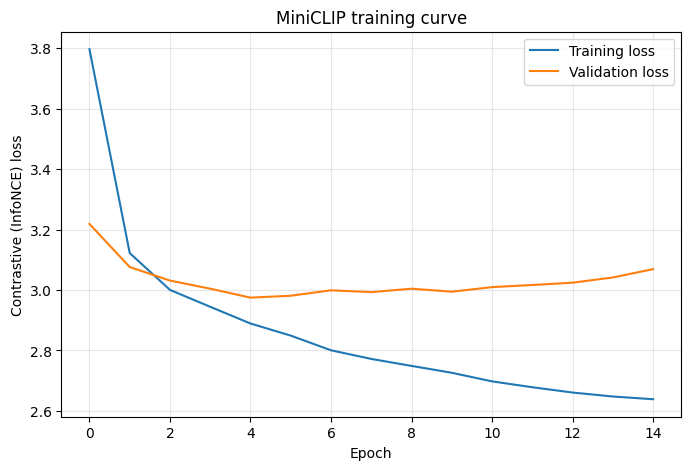

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history["loss"], label="Training loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Contrastive (InfoNCE) loss")
plt.title("MiniCLIP training curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 9 — Visualize a Similarity Matrix

Let's look at the actual `image x caption` similarity matrix for one batch, the same way the original notebook visualized cosine similarity. A well-trained model should show a bright diagonal: each image most strongly matches its own caption.

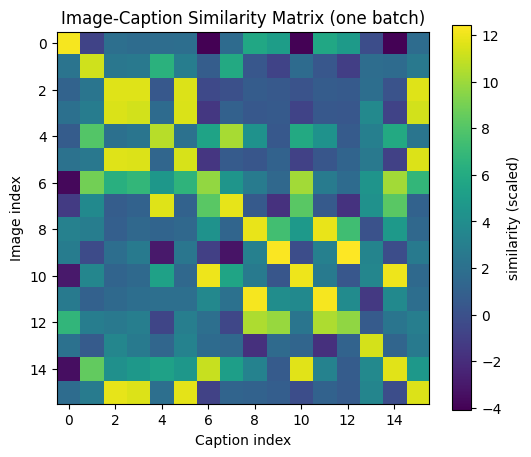

In [ ]:
mini_clip.eval()
images, tokens, labels = next(iter(test_loader))
images, tokens = images[:16].to(device), tokens[:16].to(device)

with torch.no_grad():
    logits_per_image, _, _, _ = mini_clip(images, tokens)

plt.figure(figsize=(6, 5))
plt.imshow(logits_per_image.cpu().numpy(), cmap="viridis")
plt.colorbar(label="similarity (scaled)")
plt.xlabel("Caption index")
plt.ylabel("Image index")
plt.title("Image-Caption Similarity Matrix (one batch)")
plt.show()

**Question:** do you see a bright diagonal? Remember the caveat from Step 2 -- if two images of the *same class* land in this batch, you might see a bright off-diagonal cell too (their captions are near-identical in meaning, even though the contrastive loss treats them as negatives). Is that a bug, or an expected side effect of the templated-caption design?

# Part 2 — Zero-Shot Classification With Our From-Scratch MiniCLIP

Just like the original notebook's zero-shot section: encode one text prompt per class (`"a photo of a {class}"`), encode a test image, and pick the class whose prompt embedding is most similar to the image embedding. No task-specific training at all -- the model was only ever trained to match images with captions, never explicitly told "classify this image".

In [ ]:
def zero_shot_predict(model, images, class_names, device):
    model.eval()
    prompts = [f"a photo of a {name}" for name in class_names]
    prompt_tokens = torch.tensor([encode_caption(p) for p in prompts], dtype=torch.long).to(device)

    with torch.no_grad():
        text_embeds = F.normalize(model.text_encoder(prompt_tokens), dim=-1)   # (num_classes, embed_dim)
        image_embeds = F.normalize(model.image_encoder(images.to(device)), dim=-1)  # (batch, embed_dim)
        similarities = image_embeds @ text_embeds.t()                          # (batch, num_classes)

    return torch.argmax(similarities, dim=1).cpu()

In [ ]:
all_preds = []
all_true = []

for images, _, labels in test_loader:
    preds = zero_shot_predict(mini_clip, images, class_names, device)
    all_preds.append(preds)
    all_true.append(labels)

y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_true).numpy()

accuracy = (y_pred == y_true).mean()
print(f"MiniCLIP zero-shot accuracy on CIFAR-10 test set: {accuracy:.4f}")
print(f"(chance level for 10 classes: {1/10:.4f})")

MiniCLIP zero-shot accuracy on CIFAR-10 test set: 0.8710
(chance level for 10 classes: 0.1000)


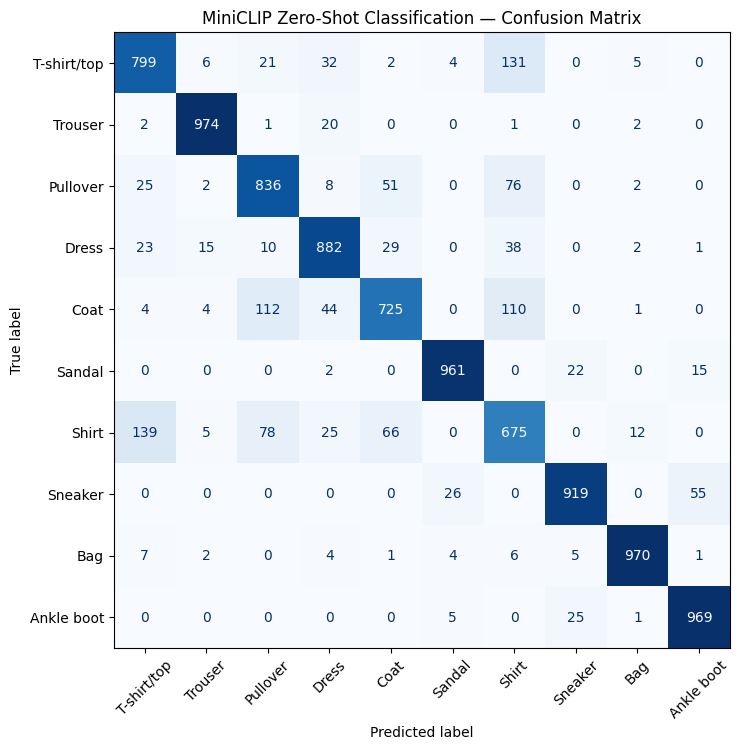

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.80      0.80      1000
     Trouser       0.97      0.97      0.97      1000
    Pullover       0.79      0.84      0.81      1000
       Dress       0.87      0.88      0.87      1000
        Coat       0.83      0.72      0.77      1000
      Sandal       0.96      0.96      0.96      1000
       Shirt       0.65      0.68      0.66      1000
     Sneaker       0.95      0.92      0.93      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.93      0.97      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [ ]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("MiniCLIP Zero-Shot Classification — Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

# Part 3 — Comparing With a Real Pretrained CLIP

Our MiniCLIP is tiny and trained on a tiny amount of data. Let's compare it against OpenAI's actual pretrained CLIP model, on the **exact same FashionMNIST test set**, to see what pretraining at scale actually buys you.

**A more robust install than the original notebook:** no uninstalling, no exact version pinning -- just a plain, up-to-date install. If you still hit an import error after running this cell on Colab, the standard fix is `Runtime -> Restart runtime` and re-running from the top (a stale, already-imported version of a library can linger in memory otherwise).

In [ ]:
%pip install -q -U transformers

In [ ]:
import torch
from transformers import CLIPProcessor, CLIPModel

clip_model_id = "openai/clip-vit-base-patch32"

clip_processor = CLIPProcessor.from_pretrained(clip_model_id)
clip_model = CLIPModel.from_pretrained(clip_model_id).to(device)
clip_model.eval()

print("Pretrained CLIP loaded.")

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Pretrained CLIP loaded.


### Safety net: making Part 3 self-contained

If you restarted the kernel and jumped straight to Part 3 without re-running Parts 1-2, variables like `class_names` and `test_dataset` won't exist yet, and you'd hit a `NameError`. The cell below checks for that and rebuilds the minimum needed from scratch if so -- so Part 3 works whether or not you ran the earlier parts in this kernel session. (The normal, faster path is still to run all cells top to bottom in one go.)

In [ ]:
if "class_names" not in dir() or "test_dataset" not in dir():
    print("class_names / test_dataset not found in this session -- rebuilding them now "
          "(this means Parts 1-2 weren't run in this kernel session; consider Kernel > "
          "Restart and running all cells top to bottom instead, next time).")

    import random
    from torch.utils.data import Dataset
    from torchvision import datasets, transforms

    img_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])

    test_raw = datasets.FashionMNIST(root="./data", train=False, download=True)
    class_names = test_raw.classes

    class ImageCaptionDataset(Dataset):
        def __init__(self, base_dataset, class_names, templates, transform):
            self.base_dataset = base_dataset
            self.class_names = class_names
            self.templates = templates
            self.transform = transform

        def __len__(self):
            return len(self.base_dataset)

        def __getitem__(self, idx):
            image, label = self.base_dataset[idx]
            image = self.transform(image)
            caption = random.choice(self.templates).format(self.class_names[label])
            return image, caption, label

    CAPTION_TEMPLATES = ["a photo of a {}", "an image of a {}", "a picture of a {}", "this is a photo of a {}"]
    test_dataset = ImageCaptionDataset(test_raw, class_names, CAPTION_TEMPLATES, img_transform)

print("class_names:", class_names)
print("test_dataset size:", len(test_dataset))

class_names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
test_dataset size: 10000


We reuse the **same** FashionMNIST test set as Parts 1-2 (via `torchvision`, not Hugging Face `datasets`, so there's no dependency overlap or version conflict to worry about), and the same `"a photo of a {class}"` prompt template, for a fair, apples-to-apples comparison.

### A note on `get_text_features` / `get_image_features` across `transformers` versions

Depending on your installed `transformers` version, `CLIPModel.get_text_features(...)` and `get_image_features(...)` return **either** a plain tensor directly, **or** a `BaseModelOutputWithPooling` object whose `.pooler_output` holds those embeddings instead (an API change introduced in some releases). We use a small helper so this notebook works either way, instead of silently producing wrong results on the "other" version.

In [ ]:
def extract_features(output):
    """Works whether get_text_features/get_image_features returns a plain tensor
    (older transformers) or a BaseModelOutputWithPooling object (newer transformers,
    where the embeddings live in .pooler_output)."""
    return output.pooler_output if hasattr(output, "pooler_output") else output

In [ ]:
clip_prompts = [f"a photo of a {name}" for name in class_names]

with torch.no_grad():
    label_tokens = clip_processor(text=clip_prompts, return_tensors="pt", padding=True).to(device)
    label_embeds = extract_features(clip_model.get_text_features(**label_tokens))
    label_embeds = F.normalize(label_embeds, dim=-1)

print("label_embeds shape:", label_embeds.shape)

label_embeds shape: torch.Size([10, 512])


In [ ]:
from PIL import Image

def to_pil(image_tensor):
    # image_tensor is normalized to [-1, 1]; undo that and convert to a PIL image.
    # Our dataset is grayscale (1 channel), but the pretrained CLIP expects RGB,
    # so we convert explicitly -- .convert("RGB") just duplicates the single
    # channel into three identical ones, which is what CLIP's own preprocessing
    # would do anyway for a grayscale input.
    image_tensor = (image_tensor * 0.5 + 0.5).clamp(0, 1)
    array = (image_tensor.squeeze(0).numpy() * 255).astype("uint8")  # (H, W), single channel
    return Image.fromarray(array, mode="L").convert("RGB")


pretrained_preds = []
pretrained_true = []

eval_batch_size = 64
for i in range(0, len(test_dataset), eval_batch_size):
    batch_items = [test_dataset[j] for j in range(i, min(i + eval_batch_size, len(test_dataset)))]
    pil_images = [to_pil(img) for img, _, _ in batch_items]
    batch_labels = [lbl for _, _, lbl in batch_items]

    with torch.no_grad():
        pixel_values = clip_processor(images=pil_images, return_tensors="pt")["pixel_values"].to(device)
        image_embeds = extract_features(clip_model.get_image_features(pixel_values=pixel_values))
        image_embeds = F.normalize(image_embeds, dim=-1)
        similarities = image_embeds @ label_embeds.t()
        preds = torch.argmax(similarities, dim=1).cpu()

    pretrained_preds.append(preds)
    pretrained_true.extend(batch_labels)

pretrained_preds = torch.cat(pretrained_preds).numpy()
pretrained_true = np.array(pretrained_true)

pretrained_accuracy = (pretrained_preds == pretrained_true).mean()
print(f"Pretrained CLIP zero-shot accuracy on FashionMNIST test set: {pretrained_accuracy:.4f}")

/tmp/ipykernel_1956/5417166.py:11: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(array, mode="L").convert("RGB")


Pretrained CLIP zero-shot accuracy on CIFAR-10 test set: 0.6117


## Compare MiniCLIP vs. Pretrained CLIP

In [ ]:
import pandas as pd

comparison = pd.DataFrame([
    {"Model": "MiniCLIP (from scratch, this lab)", "Zero-shot accuracy": accuracy,
     "Training data": f"{len(train_dataset):,} templated (image, caption) pairs"},
    {"Model": "Pretrained CLIP (openai/clip-vit-base-patch32)", "Zero-shot accuracy": pretrained_accuracy,
     "Training data": "~400 million real (image, caption) pairs from the web"},
])
comparison

,Model,Zero-shot accuracy,Training data
0,"MiniCLIP (from scratch, this lab)",0.8710,"6,000 templated (image, caption) pairs"
1,Pretrained CLIP (openai/clip-vit-base-patch32),0.6117,"~400 million real (image, caption) pairs from ..."


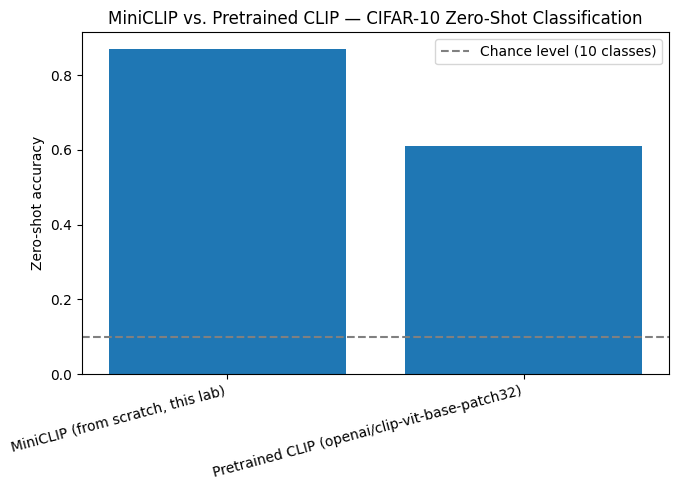

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(comparison["Model"], comparison["Zero-shot accuracy"])
plt.axhline(1/10, color="gray", linestyle="--", label="Chance level (10 classes)")
plt.ylabel("Zero-shot accuracy")
plt.title("MiniCLIP vs. Pretrained CLIP — CIFAR-10 Zero-Shot Classification")
plt.xticks(rotation=15, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

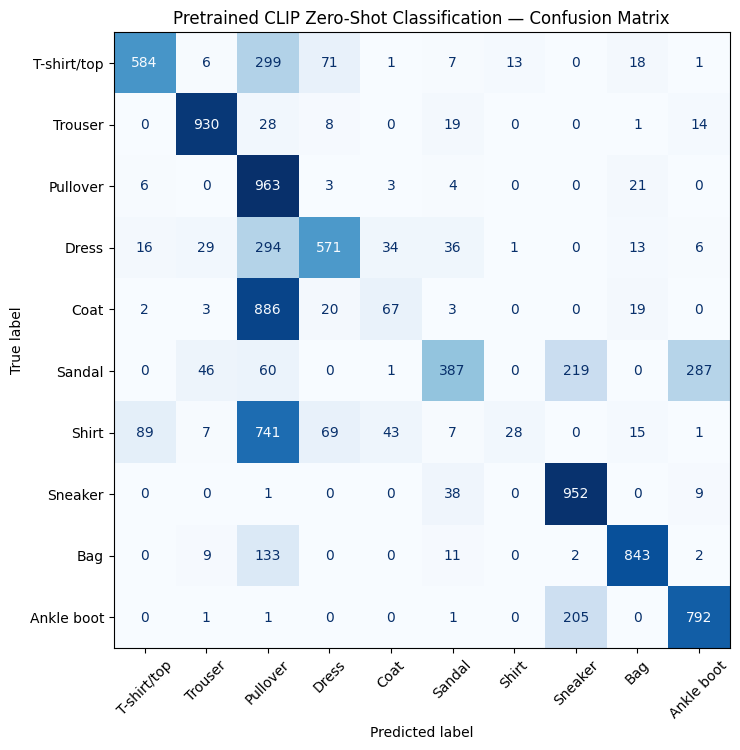

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.58      0.69      1000
     Trouser       0.90      0.93      0.92      1000
    Pullover       0.28      0.96      0.44      1000
       Dress       0.77      0.57      0.66      1000
        Coat       0.45      0.07      0.12      1000
      Sandal       0.75      0.39      0.51      1000
       Shirt       0.67      0.03      0.05      1000
     Sneaker       0.69      0.95      0.80      1000
         Bag       0.91      0.84      0.87      1000
  Ankle boot       0.71      0.79      0.75      1000

    accuracy                           0.61     10000
   macro avg       0.70      0.61      0.58     10000
weighted avg       0.70      0.61      0.58     10000



In [ ]:
cm_pretrained = confusion_matrix(pretrained_true, pretrained_preds)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm_pretrained, display_labels=class_names).plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Pretrained CLIP Zero-Shot Classification — Confusion Matrix")
plt.show()

print(classification_report(pretrained_true, pretrained_preds, target_names=class_names))

# Final Questions

1. Explain, in your own words, why the contrastive loss is applied **twice** (once over `logits_per_image`, once over `logits_per_text`) rather than just once.
2. Why do we **L2-normalize** the image and text embeddings before computing their similarity? What would change if we didn't?
3. What is the role of `logit_scale` (the temperature)? What would training look like with a fixed temperature of `1.0` versus a very large one like `100.0`?
4. Revisit the caveat from Step 2: captions are templated per *class*, not written per *image*. Explain concretely how this could make the contrastive loss's implicit "negative pairs" assumption slightly wrong, and why this mostly still works well enough for zero-shot classification.
5. Compare MiniCLIP's and the pretrained CLIP's zero-shot accuracy. How big is the gap? What does that tell you about the relationship between training data scale and zero-shot generalization?
6. Look at both confusion matrices. Do MiniCLIP and the pretrained CLIP tend to confuse the *same* pairs of classes (e.g. cat/dog, automobile/truck), or different ones? What might that tell you about what each model actually learned to focus on?
7. Zero-shot classification means the model was never trained on a "classify this CIFAR-10 image" task, only on "match this image to its caption". Why does this still let it do classification at all?
8. If you wanted to improve MiniCLIP's zero-shot accuracy without simply switching to the pretrained model, what would you try first: a bigger image encoder, a better text encoder, more/better captions, more training epochs, or something else? Justify your choice.

# Answer

1. The goal is to retrieve a caption from an image but also to do the reverse, hence the importance of computing the loss over both the image columns and the text rows.

2. This normalization removes the influence of vector magnitude, which is irrelevant here and would distort the distances used to compare positive and negative pairs. Only the direction matters.

3. The temperature controls how peaked the distribution is, i.e. how sharply the model chooses among candidates.

4. With diverse captions, an image and its associated caption would be treated as a negative for other captions that are semantically identical, and the contrastive loss would penalize them (e.g. "this is a picture of" and "a photo of").

5. MiniCLIP: 87%\
OpenAI's pretrained CLIP: 61%\
MiniCLIP was trained directly on the exact FashionMNIST distribution with the exact templates used at test time. OpenAI's CLIP is more general but worse on this specific case.

6. Both models tend to confuse semantically or visually close classes: for example, tops (T-shirt, Pullover, Coat, Shirt) or shoes (Sandal, Sneaker, Ankle Boot). But only OpenAI's CLIP shows weaknesses on some clothing classes (such as Shirt or Coat), because the representations it learned from general images do not align perfectly with the simplistic, highly specific structure of FashionMNIST.

7. Zero-shot classification works because the model is forced to project close textual and visual concepts to the same place in the latent space. The captions then act as anchors in this space. Classifying an image simply amounts to finding the geometrically closest text anchor (maximum cosine similarity).

8. To improve MiniCLIP without changing the model, the priority would be to introduce more complex captions (text data augmentation) or to use a more powerful text encoder such as BERT (our current encoder averages the word embeddings, which is problematic for long sentences and does not focus on the important words, here the class names).